# NB04 — Classifier Ablation

เทรน ResNet-50 (ImageNet-pretrained, fine-tune all) จำแนก 399 species บน Pl@ntNet train split วัดผลบน test split metric หลัก macro F1 บน 15 rare species เปรียบเทียบ 4 augmentation conditions (A-D) ต่างกันเฉพาะวิธี augment 15 rare species

## Conditions
- A: none (baseline)
- B: traditional aug (rotate/flip)
- C: FLUX zero-shot synthetic (รอ NB03)
- D: LoRA-Boost synthetic ours (รอ NB03)

## Section 1) Setup & config

path, seed, CONDITIONS dict, โหลด splits/species จาก NB01 ตัว rare_ids ดึงจาก species.csv
(is_rare flag) ไม่มีไฟล์ rare แยก

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader

ROOT = Path('/workspace/lora-boost')
META = ROOT / 'data' / 'metadata'
IMG_ROOT = ROOT / 'data' / 'raw' / 'plantnet_300K' / 'images'
SYNTH_ROOT = ROOT / 'data' / 'synthetic'
RESULTS = ROOT / 'results' / 'nb04'
RESULTS.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = 'cuda'

CONDITIONS = {
    'A': {'name': 'baseline (no aug)', 'rare_aug': None},
    'B': {'name': 'traditional aug',   'rare_aug': 'traditional'},
    'C': {'name': 'FLUX zero-shot',    'rare_aug': 'flux_zeroshot'},
    'D': {'name': 'LoRA-Boost (ours)', 'rare_aug': 'lora_boost'},
}

splits_df = pd.read_csv(META / 'splits.csv', dtype={'species_id': str})
species_df = pd.read_csv(META / 'species.csv', dtype={'species_id': str})
rare_ids = species_df.loc[species_df.is_rare, 'species_id'].tolist()
val_df = splits_df[splits_df.split == 'val']
test_df = splits_df[splits_df.split == 'test']

print(f'device :\t{torch.cuda.get_device_name(0)}')
print(f'splits :\t{len(splits_df):,} images')
print(f'species:\t{species_df.species_id.nunique()}')
print(f'rare   :\t{len(rare_ids)}')

device :	NVIDIA RTX PRO 4500 Blackwell
splits :	239,932 images
species:	399
rare   :	15


## Section 2) Decide T (rare fill target)

ดู train count distribution ทั้ง dataset + count ของ rare แต่ละตัว แล้วเลือก T (จำนวนภาพต่อ
rare species หลัง augment) augment เฉพาะ rare common ไม่แตะ ทุก condition (B/C/D) เติมถึง T
เท่ากัน เพื่อ isolate "แหล่งที่มา augment" ไม่ใช่ "จำนวนภาพ"
ข้อจำกัด: synthetic ที่ตัวเล็กสุดต้องการ = T - real_train ต้องไม่เกิน supply NB03

In [2]:
train_df = splits_df[splits_df.split == 'train']
counts = train_df.groupby('species_id').size()
rare_counts = counts[counts.index.isin(rare_ids)].sort_values()

print('dataset train count (399 sp)')
for q in (10, 25, 50, 75, 90):
    print(f'  p{q:<2}:\t{counts.quantile(q / 100):.0f}')
print(f'  min/max:\t{counts.min()} / {counts.max()}')

print(f'\nrare train count (n={len(rare_counts)})')
for sid, c in rare_counts.items():
    name = species_df.loc[species_df.species_id == sid, 'scientific_name'].iat[0]
    print(f'  {c:>3}\t{name}')

print('\nsynthetic need vs candidate T (need = T - real, worst = smallest rare)')
for T in (200, 250, 300, 350):
    need = (T - rare_counts).clip(lower=0)
    print(f'  T={T}\tmax_need={need.max():>3}\ttotal_need={need.sum():>5}')

dataset train count (399 sp)
  p10:	23
  p25:	50
  p50:	121
  p75:	417
  p90:	1284
  min/max:	12 / 5426

rare train count (n=15)
   20	Nepenthes vieillardii Hook. f.
   23	Vanilla planifolia Jacks. ex Andrews
   28	Petiveria alliacea L.
   33	Pereskia aculeata Mill.
   36	Pongamia pinnata (L.) Pierre
   37	Kigelia africana (Lam.) Benth.
   38	Alocasia odora (Lindl.) K.Koch
   40	Pereskia grandifolia Haw.
   47	Barringtonia asiatica (L.) Kurz
   49	Tradescantia zebrina Heynh. ex Bosse
   49	Cobaea scandens Cav.
   51	Dendrobium victoriae-reginae Loher
   56	Lagenaria siceraria (Molina) Standl.
   66	Acalypha indica L.
   71	Gomphocarpus physocarpus E.Mey.

synthetic need vs candidate T (need = T - real, worst = smallest rare)
  T=200	max_need=180	total_need= 2356
  T=250	max_need=230	total_need= 3106
  T=300	max_need=280	total_need= 3856
  T=350	max_need=330	total_need= 4606


In [3]:
T = 200

fill = (T - rare_counts).clip(lower=0)
pct = (counts < T).mean() * 100
print(f'T = {T}\t({pct:.0f}th pct, above median {counts.median():.0f})')
print(f'\nfill plan (real -> +synth -> T)')
for sid, c in rare_counts.items():
    print(f'  {c:>2} -> +{fill[sid]:>3} -> {T}')
print(f'\nmax synth/sp:\t{fill.max()}')
print(f'total synth :\t{fill.sum()}')

T = 200	(63th pct, above median 121)

fill plan (real -> +synth -> T)
  20 -> +180 -> 200
  23 -> +177 -> 200
  28 -> +172 -> 200
  33 -> +167 -> 200
  36 -> +164 -> 200
  37 -> +163 -> 200
  38 -> +162 -> 200
  40 -> +160 -> 200
  47 -> +153 -> 200
  49 -> +151 -> 200
  49 -> +151 -> 200
  51 -> +149 -> 200
  56 -> +144 -> 200
  66 -> +134 -> 200
  71 -> +129 -> 200

max synth/sp:	180
total synth :	2356


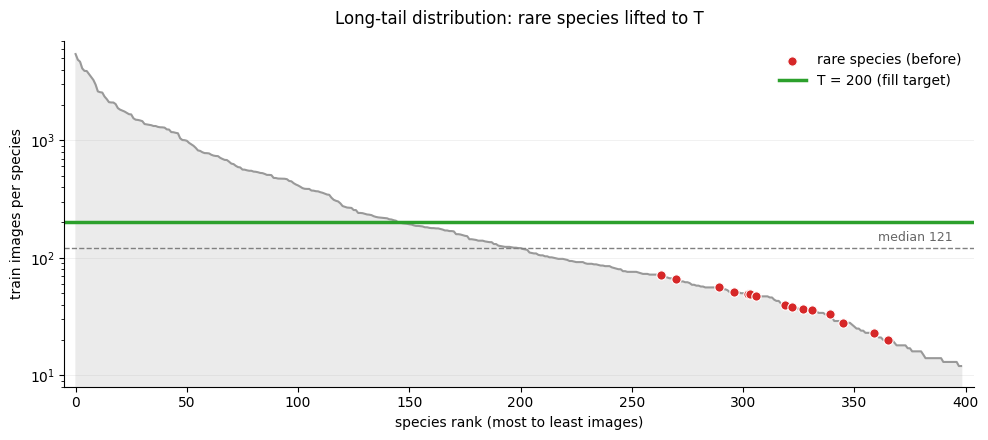

In [4]:
import matplotlib.pyplot as plt

sorted_idx = counts.sort_values(ascending=False).index
sorted_counts = counts[sorted_idx].values
rare_mask = sorted_idx.isin(rare_ids)
rank = np.arange(len(sorted_counts))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(rank, sorted_counts, 1, color='0.92', zorder=0)
ax.plot(rank, sorted_counts, color='0.6', lw=1.5, zorder=1)
ax.scatter(rank[rare_mask], sorted_counts[rare_mask], color='#d62728',
           s=45, zorder=3, edgecolor='white', linewidth=0.8, label='rare species (before)')

ax.axhline(T, color='#2ca02c', lw=2.5, zorder=2, label=f'T = {T} (fill target)')
ax.axhline(counts.median(), color='0.5', ls='--', lw=1, zorder=2)
ax.text(len(rank) - 5, counts.median() * 1.15, f'median {counts.median():.0f}',
        ha='right', fontsize=9, color='0.4')

ax.set_yscale('log')
ax.set_xlim(-5, len(rank) + 5)
ax.set_ylim(8, sorted_counts.max() * 1.3)
ax.set_xlabel('species rank (most to least images)')
ax.set_ylabel('train images per species')
ax.set_title('Long-tail distribution: rare species lifted to T', fontsize=12, pad=12)
ax.legend(loc='upper right', frameon=False)
ax.grid(axis='y', alpha=0.25, lw=0.5)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS / 'fig_longtail_rank.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3) Synthetic manifest

โหลด synthetic ที่ curate แล้วจาก NB03 (`synthetic_manifest.csv`) cols: path, species_id, source
source = `flux_zeroshot` (C) / `lora_boost` (D) ถ้ายังไม่มีไฟล์คืน df ว่าง
condition ไหน source ยังไม่พร้อมข้ามไปก่อน

In [5]:
SYNTH_MANIFEST = META / 'synthetic_manifest.csv'
SYNTH_COLS = ['path', 'species_id', 'source']

def load_synth_manifest():
    # อ่าน manifest จาก NB03 ยังไม่มีไฟล์คืน df ว่าง schema เดียวกัน
    if not SYNTH_MANIFEST.exists():
        return pd.DataFrame(columns=SYNTH_COLS)
    df = pd.read_csv(SYNTH_MANIFEST, dtype={'species_id': str})
    return df[SYNTH_COLS]

def synth_counts(source):
    # นับ synthetic ต่อ rare species ของ source นี้ index=rare_ids
    m = load_synth_manifest()
    m = m[(m.source == source) & (m.species_id.isin(rare_ids))]
    return m.groupby('species_id').size().reindex(rare_ids, fill_value=0)

def synth_available(source):
    # source พร้อมเมื่อมี synthetic ครบทุก rare species (>=1 ภาพต่อตัว)
    return bool((synth_counts(source) > 0).all())

print(f'manifest exists:\t{SYNTH_MANIFEST.exists()}')
for src in ('flux_zeroshot', 'lora_boost'):
    cov = int((synth_counts(src) > 0).sum())
    print(f'{src:>14}:\tavailable={synth_available(src)}\tcovered={cov}/{len(rare_ids)}')

manifest exists:	True
 flux_zeroshot:	available=True	covered=15/15
    lora_boost:	available=True	covered=15/15


## Section 4) Build train df per condition

ประกอบ train list ราย condition คืน df cols: path, species_id, source
- common (384 sp): natural count เหมือนกันทุก condition source=`real`
- rare (15 sp): เติมถึง T ตาม condition
  - A: ไม่เติม ปล่อย natural count
  - B: duplicate ภาพจริงถึง T source=`real_dup`
  - C/D: เติม synthetic จาก manifest ถึง T source=`flux_zeroshot`/`lora_boost`
path เป็น relative (common ต่อ IMG_ROOT, synthetic ต่อ SYNTH_ROOT) เติม root ตอนโหลดใน Dataset

In [6]:
def _real_train_pool():
    # train rows ทั้งหมด ติด source=real path relative ต่อ IMG_ROOT
    df = splits_df[splits_df.split == 'train'][['path', 'species_id']].copy()
    df['source'] = 'real'
    return df

def _fill_rare(rare_real, rare_aug, T, seed):
    # เติม rare แต่ละ sp ถึง T ตาม aug strategy คืน list ของ df ที่จะ append
    parts = [rare_real]
    if rare_aug == 'traditional':
        # B: duplicate ภาพจริงถึง T (transform จริงทำใน Dataset) source=real_dup
        for sid, g in rare_real.groupby('species_id'):
            n_fill = T - len(g)
            if n_fill <= 0:
                continue
            dup = g.sample(n=n_fill, replace=True, random_state=seed).copy()
            dup['source'] = 'real_dup'
            parts.append(dup)
    else:
        # C/D: เติม synthetic จาก manifest ถึง T
        man = load_synth_manifest()
        man = man[man.source == rare_aug].copy()
        man['path'] = rare_aug + '/' + man['path']  # mark ว่าอยู่ใต้ SYNTH_ROOT
        for sid, g in rare_real.groupby('species_id'):
            n_fill = T - len(g)
            avail = man[man.species_id == sid]
            take = avail.sample(n=min(n_fill, len(avail)), random_state=seed) if n_fill > 0 else avail.iloc[:0]
            parts.append(take[['path', 'species_id', 'source']])
    return parts

def build_train_df(cond_key, T, seed=SEED):
    rare_aug = CONDITIONS[cond_key]['rare_aug']
    pool = _real_train_pool()
    common = pool[~pool.species_id.isin(rare_ids)]
    rare_real = pool[pool.species_id.isin(rare_ids)]

    parts = [common]
    if rare_aug is None:
        parts.append(rare_real)
    else:
        parts += _fill_rare(rare_real, rare_aug, T, seed)

    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

In [7]:
for k in ('A', 'B', 'C', 'D'):
    df = build_train_df(k, T)
    rare = df[df.species_id.isin(rare_ids)]
    rc = rare.groupby('species_id').size()
    print(f"{k}: {len(df):,} rows\trare {rare.species_id.nunique()}sp"
          f"\trare/sp {rc.min()}-{rc.max()}\tsrc {df.source.value_counts().to_dict()}")

A: 167,960 rows	rare 15sp	rare/sp 20-71	src {'real': 167960}
B: 170,316 rows	rare 15sp	rare/sp 200-200	src {'real': 167960, 'real_dup': 2356}
C: 170,316 rows	rare 15sp	rare/sp 200-200	src {'real': 167960, 'flux_zeroshot': 2356}
D: 170,316 rows	rare 15sp	rare/sp 200-200	src {'real': 167960, 'lora_boost': 2356}


## Section 5) Dataset & transforms

อ่านภาพจาก df เลือก transform ตาม source
- base: resize 224 + ImageNet normalize (real, synthetic, val/test)
- traditional: base + rotate/flip/jitter เฉพาะ real_dup ของ B
  
synthetic resolve path ใต้ SYNTH_ROOT ที่เหลือใต้ IMG_ROOT

In [8]:
import torchvision.transforms as TF

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

base_tf = TF.Compose([
    TF.Resize((IMG_SIZE, IMG_SIZE)),
    TF.ToTensor(),
    TF.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

traditional_tf = TF.Compose([
    TF.Resize((IMG_SIZE, IMG_SIZE)),
    TF.RandomHorizontalFlip(),
    TF.RandomRotation(30),
    TF.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    TF.ToTensor(),
    TF.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = base_tf  # val/test ใช้ base เหมือนกัน

species_sorted = sorted(species_df.species_id.tolist())
sid_to_label = {sid: i for i, sid in enumerate(species_sorted)}
label_to_sid = {i: sid for sid, i in sid_to_label.items()}
print(f'classes :\t{len(sid_to_label)}')
print(f'img size:\t{IMG_SIZE}')

classes :	399
img size:	224


In [9]:
from torch.utils.data import Dataset
from PIL import Image

class PlantDataset(Dataset):
    def __init__(self, df, train=True):
        # df cols: path, species_id, source
        self.paths = df.path.tolist()
        self.sources = df.source.tolist() if 'source' in df else ['real'] * len(df)
        self.labels = [sid_to_label[s] for s in df.species_id]
        self.train = train

    def __len__(self):
        return len(self.paths)

    def _resolve(self, path, source):
        # synthetic อยู่ใต้ SYNTH_ROOT ที่เหลือ (real, real_dup) ใต้ IMG_ROOT
        root = SYNTH_ROOT if source in ('flux_zeroshot', 'lora_boost') else IMG_ROOT
        return root / path

    def __getitem__(self, i):
        img = Image.open(self._resolve(self.paths[i], self.sources[i])).convert('RGB')
        if self.train and self.sources[i] == 'real_dup':
            tf = traditional_tf
        else:
            tf = base_tf if self.train else eval_tf
        return tf(img), self.labels[i]

In [10]:
from torch.utils.data import DataLoader

df_B = build_train_df('B', T)
ds = PlantDataset(df_B, train=True)
dl = DataLoader(ds, batch_size=32, shuffle=True, num_workers=2)

x, y = next(iter(dl))
print(f'batch x :\t{tuple(x.shape)}\t{x.dtype}')
print(f'batch y :\t{tuple(y.shape)}\t{y.dtype}')
print(f'x range :\t{x.min():.2f} to {x.max():.2f}')
print(f'labels  :\t{y[:8].tolist()}')

batch x :	(32, 3, 224, 224)	torch.float32
batch y :	(32,)	torch.int64
x range :	-2.12 to 2.64
labels  :	[93, 0, 84, 285, 117, 110, 208, 8]


## Section 6) Sanity checks

verify fairness ก่อนเทรน
- val/test เป็น real ล้วน ไม่มี synthetic/dup ปน
- common เหมือนกันทุก condition (ต่างแค่ rare)
- rare count ต่อ condition ตรงตามออกแบบ

In [11]:
rows = []
ref_common = None
for k in CONDITIONS:
    df = build_train_df(k, T)
    common = set(df[(df.source == 'real') & (~df.species_id.isin(rare_ids))].path)
    ref_common = common if ref_common is None else ref_common
    rc = df[df.species_id.isin(rare_ids)].groupby('species_id').size()
    rows.append({'cond': k, 'rows': len(df), 'common_match': common == ref_common,
                 'rare_total': rc.sum(), 'rare_min': rc.min(), 'rare_max': rc.max()})

display(pd.DataFrame(rows).set_index('cond'))
print(f'val {len(val_df):,} / test {len(test_df):,} (real only)')

,rows,common_match,rare_total,rare_min,rare_max
cond,,,,,
A,167960,True,644,20,71
B,170316,True,3000,200,200
C,170316,True,3000,200,200
D,170316,True,3000,200,200


val 35,986 / test 35,986 (real only)


## Section 7) Model builder

ResNet-50 ImageNet-pretrained เปลี่ยน fc เป็น 399 classes fine-tune ทั้ง model
set seed ก่อนสร้างทุกครั้ง ให้ทุก condition เริ่มจาก init เดียวกัน

In [12]:
import random
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def build_model(n_classes=len(sid_to_label)):
    set_seed()  # init fc เหมือนกันทุก condition
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(DEVICE)

model = build_model()
n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'classes  :\t{model.fc.out_features}')
print(f'params   :\t{n_params / 1e6:.1f}M')
print(f'trainable:\t{n_train / 1e6:.1f}M\t(fine-tune all)')

classes  :	399
params   :	24.3M
trainable:	24.3M	(fine-tune all)


## Section 8) Train & evaluate

Phase 1: รัน A และ B ถึง 25 epoch (เพดาน 30) log val ทุก epoch หาจุด rare F1 พีค -> ล็อก EPOCHS

Phase 2: รัน A/B/C/D ใหม่ที่ EPOCHS เท่ากัน ไม่ดู val ไม่ early stop

checkpoint ทุก epoch (model+optim+sched+epoch) resume ได้ถ้า disconnect

hyperparams เหมือนกันทุก condition ต่างแค่ data

In [13]:
import torch.optim as optim

MAX_EPOCHS = 30
PHASE1_EPOCHS = 25
BATCH_SIZE = 128
LR_BACKBONE = 1e-4
LR_FC = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

CKPT_DIR = RESULTS / 'ckpt'
CKPT_DIR.mkdir(exist_ok=True)

def make_optimizer(model):
    # split LR: backbone ต่ำ (pretrained), fc สูง (สุ่มใหม่)
    fc_params = list(model.fc.parameters())
    fc_ids = {id(p) for p in fc_params}
    backbone = [p for p in model.parameters() if id(p) not in fc_ids]
    return optim.AdamW([
        {'params': backbone, 'lr': LR_BACKBONE},
        {'params': fc_params, 'lr': LR_FC},
    ], weight_decay=WEIGHT_DECAY)

print(f'batch    :\t{BATCH_SIZE}')
print(f'lr       :\tbackbone {LR_BACKBONE} / fc {LR_FC}')
print(f'max epoch:\t{MAX_EPOCHS}')

batch    :	128
lr       :	backbone 0.0001 / fc 0.001
max epoch:	30


In [14]:
def ckpt_path(cond_key):
    return CKPT_DIR / f'{cond_key}.pt'

def save_ckpt(cond_key, model, opt, sched, epoch, history):
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'opt': opt.state_dict(),
        'sched': sched.state_dict(),
        'history': history,
    }, ckpt_path(cond_key))

def load_ckpt(cond_key, model, opt, sched):
    # คืน (start_epoch, history) ถ้าไม่มี ckpt เริ่มที่ 0
    p = ckpt_path(cond_key)
    if not p.exists():
        return 0, []
    ck = torch.load(p, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    opt.load_state_dict(ck['opt'])
    sched.load_state_dict(ck['sched'])
    return ck['epoch'] + 1, ck['history']

In [15]:
from torch.optim.lr_scheduler import OneCycleLR
from tqdm.auto import tqdm

def train_one_epoch(model, loader, opt, sched, criterion):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad()
        with torch.autocast(DEVICE, dtype=torch.bfloat16):
            out = model(x)
            loss = criterion(out, y)
        loss.backward()
        opt.step()
        sched.step()
        total_loss += loss.item() * len(y)
        n += len(y)
    return total_loss / n

def train_condition(cond_key, n_epochs, eval_fn=None):
    set_seed()
    df = build_train_df(cond_key, T)
    loader = DataLoader(PlantDataset(df, train=True), batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True,
                        drop_last=True, persistent_workers=True)

    model = build_model()
    opt = make_optimizer(model)
    sched = OneCycleLR(opt, max_lr=[LR_BACKBONE, LR_FC],
                       total_steps=n_epochs * len(loader), pct_start=0.1)
    criterion = nn.CrossEntropyLoss()

    start, history = load_ckpt(cond_key, model, opt, sched)
    for epoch in range(start, n_epochs):
        loss = train_one_epoch(model, loader, opt, sched, criterion)
        row = {'epoch': epoch, 'train_loss': loss}
        if eval_fn is not None:
            row.update(eval_fn(model))
        history.append(row)
        save_ckpt(cond_key, model, opt, sched, epoch, history)
        msg = f'[{cond_key}] ep {epoch:>2} loss {loss:.3f}'
        if eval_fn is not None:
            msg += f" val_macroF1 {row.get('val_macro_f1', 0):.3f} rare {row.get('val_rare_f1', 0):.3f}"
        print(msg)
    return model, history

In [16]:
from sklearn.metrics import f1_score

rare_labels = [sid_to_label[s] for s in rare_ids]

@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, gts = [], []
    for x, y in tqdm(loader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(DEVICE, dtype=torch.bfloat16):
            out = model(x)
        preds.append(out.argmax(1).cpu())
        gts.append(y)
    return torch.cat(preds).numpy(), torch.cat(gts).numpy()

def eval_split(model, split_df):
    loader = DataLoader(PlantDataset(split_df, train=False), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)
    pred, gt = predict(model, loader)
    f1_per = f1_score(gt, pred, labels=list(range(len(sid_to_label))),
                      average=None, zero_division=0)
    return {
        'macro_f1': f1_per.mean(),
        'rare_f1': f1_per[rare_labels].mean(),
        'f1_per_class': f1_per,
    }

def make_val_eval():
    # eval_fn สำหรับ train loop log val ทุก epoch (เฟส 1)
    def _fn(model):
        r = eval_split(model, val_df)
        return {'val_macro_f1': r['macro_f1'], 'val_rare_f1': r['rare_f1']}
    return _fn

In [33]:
r = eval_split(model, val_df)
print(f'val macro F1 :\t{r["macro_f1"]:.4f}')
print(f'val rare F1  :\t{r["rare_f1"]:.4f}')
print(f'f1 per class :\t{r["f1_per_class"].shape}')

val macro F1 :	0.0006
val rare F1  :	0.0013
f1 per class :	(399,)


### Phase 1

In [42]:
import shutil
shutil.rmtree(CKPT_DIR, ignore_errors=True)
CKPT_DIR.mkdir(exist_ok=True)

print(f'PHASE 1: tune epochs on condition A (max {PHASE1_EPOCHS} epoch)')
print(f'run A long, log val every epoch, find rare F1 peak -> lock EPOCHS\n')

model_A, hist_A = train_condition('A', PHASE1_EPOCHS, eval_fn=make_val_eval())

PHASE 1: tune epochs on condition A (max 25 epoch)
run A long, log val every epoch, find rare F1 peak -> lock EPOCHS



  0%|          | 0/1312 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

[A] ep  0 loss 2.869 val_macroF1 0.408 rare 0.139


  0%|          | 0/1312 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

[A] ep 23 loss 0.000 val_macroF1 0.616 rare 0.510


  0%|          | 0/1312 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

[A] ep 24 loss 0.000 val_macroF1 0.615 rare 0.492


In [45]:
import shutil
ckpt_b = ckpt_path('B')
if ckpt_b.exists():
    ckpt_b.unlink()  # ลบ ckpt B เก่า เริ่มสด (ไม่แตะ A.pt)

print(f'PHASE 1: tune epochs on condition B (max {PHASE1_EPOCHS} epoch)')
print(f'compare overfit speed vs A (B has 200 rare/sp)\n')

model_B, hist_B = train_condition('B', PHASE1_EPOCHS, eval_fn=make_val_eval())

PHASE 1: tune epochs on condition B (max 25 epoch)
compare overfit speed vs A (B has 200 rare/sp)



  0%|          | 0/1330 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

[B] ep  0 loss 2.874 val_macroF1 0.398 rare 0.213


  0%|          | 0/1330 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

[B] ep 23 loss 0.000 val_macroF1 0.623 rare 0.527


  0%|          | 0/1330 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

[B] ep 24 loss 0.000 val_macroF1 0.622 rare 0.533


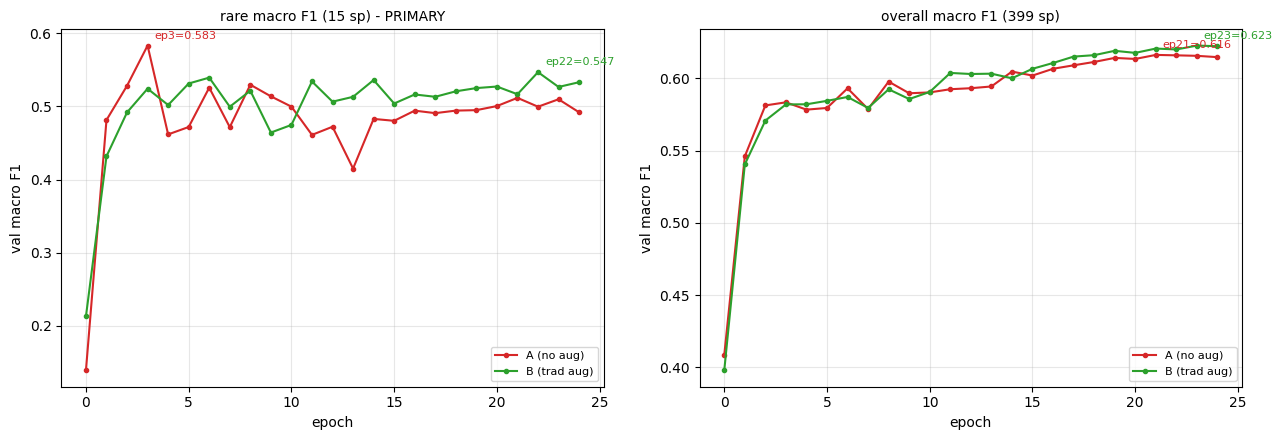

In [17]:
import matplotlib.pyplot as plt
import json

h = json.load(open(RESULTS / 'phase1_history.json'))
hist_A, hist_B = h['A'], h['B']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
series = [(hist_A, 'A (no aug)', 'tab:red'),
          (hist_B, 'B (trad aug)', 'tab:green')]

for ax, key, title in [(axes[0], 'val_rare_f1', 'rare macro F1 (15 sp) - PRIMARY'),
                       (axes[1], 'val_macro_f1', 'overall macro F1 (399 sp)')]:
    for hist, name, c in series:
        ep = [r['epoch'] for r in hist]
        v = [r[key] for r in hist]
        ax.plot(ep, v, '-o', ms=3, color=c, label=name)
        peak = max(range(len(v)), key=lambda i: v[i])
        ax.annotate(f'ep{ep[peak]}={v[peak]:.3f}', (ep[peak], v[peak]),
                    textcoords='offset points', xytext=(5, 5), fontsize=8, color=c)
    ax.set_xlabel('epoch')
    ax.set_ylabel('val macro F1')
    ax.set_title(title, fontsize=10)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'fig_phase1_AB.png', dpi=130, bbox_inches='tight')
plt.show()

#### เลือก EPOCHS = 12

จาก phase 1 (รัน A กับ B ยาว 25 epoch ดู val curve):

A (ไม่ aug, rare 20-71/sp) พีคที่ ep3 (rare F1 0.583) แล้วร่วง overfit เร็วเพราะภาพน้อย
B (trad aug, rare 200/sp) ไม่พีคเร็วแบบ A แต่ค่อยๆไต่ขึ้นยาวถึง ep22 (0.547) — ภาพเยอะกว่าเลย overfit ช้ากว่า

ปัญหาคือถ้า lock ตาม A (ep3) จะตัด C/D ก่อนมันไต่ถึงพีค เพราะ C/D มี 200/sp เหมือน B จะ overfit ช้าแบบ B ไม่ใช่เร็วแบบ A เลยต้องเผื่อ

12 มาจาก: B ยังอยู่ขาขึ้นไม่ overfit, overall ~0.60 ใกล้ plateau (0.62) แล้ว common ไม่เสีย, A ยัง loss ไม่ถึง 0 ไม่ overfit สุดโต่ง
ไม่ไป 15-22 เพราะ B ช่วงนั้นไต่ช้ามาก (0.51->0.547) ได้ rare เพิ่มนิดเดียวแต่ A overfit ลึกขึ้น ไม่คุ้ม

In [17]:
EPOCHS = 12
print(f'EPOCHS = {EPOCHS}')

EPOCHS = 12


### Phase 2

In [18]:
import json

METRIC_DIR = RESULTS / 'metrics'
METRIC_DIR.mkdir(exist_ok=True)

def metric_path(cond_key):
    return METRIC_DIR / f'metrics_{cond_key}.json'

def cond_ready(cond_key):
    # A/B พร้อมเสมอ C/D ต้องมี synthetic ครบทุก rare
    aug = CONDITIONS[cond_key]['rare_aug']
    if aug in (None, 'traditional'):
        return True
    return synth_available(aug)

def run_phase2(cond_key):
    # เทรนที่ EPOCHS eval test เซฟ metrics ข้ามถ้าเคยรันแล้ว
    if metric_path(cond_key).exists():
        print(f'[{cond_key}] metrics exist, skip')
        return
    print(f'[{cond_key}] phase 2 train at {EPOCHS} epoch')
    model, _ = train_condition(cond_key, EPOCHS)

    test_res = eval_split(model, test_df)
    out = {
        'condition': cond_key,
        'name': CONDITIONS[cond_key]['name'],
        'epochs': EPOCHS,
        'test_macro_f1': float(test_res['macro_f1']),
        'test_rare_f1': float(test_res['rare_f1']),
        'rare_f1_per_sp': {label_to_sid[l]: float(test_res['f1_per_class'][l]) for l in rare_labels},
    }
    json.dump(out, open(metric_path(cond_key), 'w'), indent=2)
    print(f'[{cond_key}] test macroF1 {out["test_macro_f1"]:.3f} rare {out["test_rare_f1"]:.3f}')

In [20]:
import shutil
shutil.rmtree(CKPT_DIR, ignore_errors=True)
CKPT_DIR.mkdir(exist_ok=True)
print('cleared phase 1 ckpt, ready for phase 2')

cleared phase 1 ckpt, ready for phase 2


In [19]:
run_phase2('A')

[A] phase 2 train at 12 epoch


  0%|          | 0/1312 [00:00<?, ?it/s]

[A] ep  0 loss 2.297


  0%|          | 0/1312 [00:00<?, ?it/s]

[A] ep  1 loss 0.583


...

[A] ep 10 loss 0.001


  0%|          | 0/1312 [00:00<?, ?it/s]

[A] ep 11 loss 0.001


  0%|          | 0/282 [00:00<?, ?it/s]

[A] test macroF1 0.626 rare 0.644


In [20]:
run_phase2('B')

[B] phase 2 train at 12 epoch


  0%|          | 0/1330 [00:00<?, ?it/s]

[B] ep  0 loss 2.297


  0%|          | 0/1330 [00:00<?, ?it/s]

[B] ep  1 loss 0.577


...

[B] ep 10 loss 0.001


  0%|          | 0/1330 [00:00<?, ?it/s]

[B] ep 11 loss 0.001


  0%|          | 0/282 [00:00<?, ?it/s]

[B] test macroF1 0.628 rare 0.594


In [21]:
run_phase2('C') if cond_ready('C') else print('[C] not ready (synthetic missing), skip')

[C] phase 2 train at 12 epoch


  0%|          | 0/1330 [00:00<?, ?it/s]

[C] ep  0 loss 2.308


  0%|          | 0/1330 [00:00<?, ?it/s]

[C] ep  1 loss 0.593


...

[C] ep 10 loss 0.001


  0%|          | 0/1330 [00:00<?, ?it/s]

[C] ep 11 loss 0.001


  0%|          | 0/282 [00:00<?, ?it/s]

[C] test macroF1 0.630 rare 0.502


In [22]:
run_phase2('D') if cond_ready('D') else print('[D] not ready (synthetic missing), skip')

[D] phase 2 train at 12 epoch


  0%|          | 0/1330 [00:00<?, ?it/s]

[D] ep  0 loss 2.294


  0%|          | 0/1330 [00:00<?, ?it/s]

[D] ep  1 loss 0.577


...

[D] ep 10 loss 0.001


  0%|          | 0/1330 [00:00<?, ?it/s]

[D] ep 11 loss 0.001


  0%|          | 0/282 [00:00<?, ?it/s]

[D] test macroF1 0.627 rare 0.546


## Section 9) Aggregate results

อ่าน metrics ทุก condition ที่รันแล้วมาเทียบ macro F1 (rare เป็นหลัก)

In [23]:
import json

rows = []
for k in CONDITIONS:
    p = metric_path(k)
    if not p.exists():
        continue
    m = json.load(open(p))
    rows.append({'cond': k, 'name': m['name'],
                 'overall_f1': m['test_macro_f1'], 'rare_f1': m['test_rare_f1']})

res_df = pd.DataFrame(rows).set_index('cond')
a_rare = res_df.loc['A', 'rare_f1']
res_df['rare_vs_A'] = res_df['rare_f1'] - a_rare
display(res_df.round(4))

,name,overall_f1,rare_f1,rare_vs_A
cond,,,,
A,baseline (no aug),0.6258,0.6438,0.0000
B,traditional aug,0.6283,0.5936,-0.0501
C,FLUX zero-shot,0.6300,0.5020,-0.1418
D,LoRA-Boost (ours),0.6270,0.5463,-0.0975


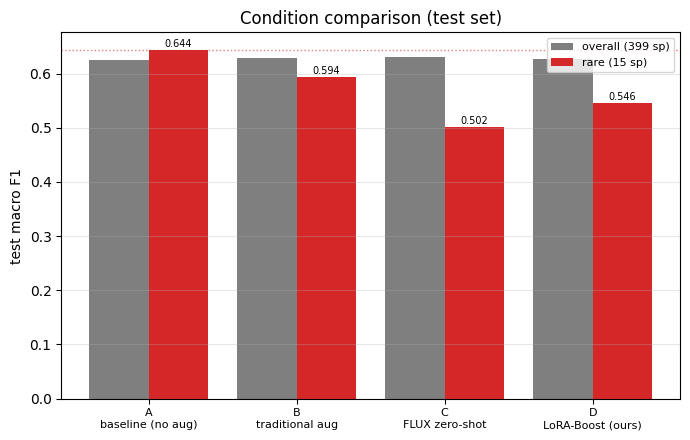

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
x = range(len(res_df))
ax.bar([i - 0.2 for i in x], res_df['overall_f1'], 0.4, label='overall (399 sp)', color='tab:gray')
ax.bar([i + 0.2 for i in x], res_df['rare_f1'], 0.4, label='rare (15 sp)', color='tab:red')

ax.axhline(res_df.loc['A', 'rare_f1'], color='tab:red', ls=':', lw=1, alpha=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{k}\n{res_df.loc[k, "name"]}' for k in res_df.index], fontsize=8)
ax.set_ylabel('test macro F1')
ax.set_title('Condition comparison (test set)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
for i, k in enumerate(res_df.index):
    ax.text(i + 0.2, res_df.loc[k, 'rare_f1'] + 0.005, f'{res_df.loc[k, "rare_f1"]:.3f}',
            ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS / 'fig_condition_compare.png', dpi=130, bbox_inches='tight')
plt.show()